# PSD Diagnostics Runner

Runs `analysis/run_psd_diagnostics.py` for real 3-D binary pore volumes (`True = pore`).
Use the real mode and optional chunking mode for large inputs.

All outputs are written to `<OUTPUT_ROOT>/psd_diag_<timestamp>_<run-name>/`.

## Environment Check

In [10]:
try:
    import cupy
    cupy.zeros(1)  # trigger CUDA init
    print('GPU EDT available (CuPy detected). GPU acceleration will be used by default.')
except Exception as _e:
    print(f'CuPy not available ({_e}). CPU EDT will be used (add --no-gpu to CLI cells to silence this).')

GPU EDT available (CuPy detected). GPU acceleration will be used by default.


## Step 3 — Configure Paths

Edit `DRIVE_PROJECT_ROOT` to match the location of the project on your Drive.

In [11]:
import os

ANALYSIS_DIR = r'C:\Users\rony.schwartz\Documents\nnUNet4SoilXrayCT\analysis'
OUTPUT_ROOT  = r'C:\Users\rony.schwartz\Documents\psd_resources\outputs'

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print(f'ANALYSIS_DIR : {ANALYSIS_DIR}')
print(f'OUTPUT_ROOT  : {OUTPUT_ROOT}')
print('analysis/ contents:', os.listdir(ANALYSIS_DIR))

ANALYSIS_DIR : C:\Users\rony.schwartz\Documents\nnUNet4SoilXrayCT\analysis
OUTPUT_ROOT  : C:\Users\rony.schwartz\Documents\psd_resources\outputs
analysis/ contents: ['colab_psd_diagnostics.ipynb', 'implementation_contract.md', 'plan.md', 'psd_diagnostics_core.py', 'run_psd_diagnostics.py', 'selected_outputs', 'vogel_psd.pdf', '__pycache__']


## Step 4 — Real Mode (binary pore volume)

Supply the path to a 3-D binary pore volume (`.npy` or `.tif`/`.tiff`; `True = pore`)
and set the physical voxel spacing in micrometres `(dz, dy, dx)`.

Edit `INPUT_VOLUME` and `VOXEL_SPACING_UM` before running.

In [5]:
# --- EDIT THESE ---
INPUT_VOLUME     = r'C:\Users\rony.schwartz\Documents\psd_resources\bnei_reem_2_otsu.npy'
VOXEL_SPACING_UM = '15.0 15.0 15.0'   # dz dy dx  (micrometres) — verify against scan metadata
RUN_NAME         = 'scan_001'
# ------------------

print(f'Input volume : {INPUT_VOLUME}')
print(f'Voxel spacing: {VOXEL_SPACING_UM} um')

Input volume : C:\Users\rony.schwartz\Documents\psd_resources\bnei_reem_2_otsu.npy
Voxel spacing: 15.0 15.0 15.0 um


## Step 5a — Crop Sub-Volume (optional)

Loads the full volume and saves a `(650 × 650 × 100)` sub-crop as a temporary `.npy` file.
Run this cell **before** Step 5 or Step 6 to analyse only a slice of the volume.
Adjust `CROP_Z_START` to slide the 100-slice window along the Z axis.


In [12]:
import numpy as np, pathlib, tifffile

# --- EDIT THIS to slide the window along Z ---
CROP_Z_START = 0          # first Z slice to include (0-indexed)
# ---------------------------------------------

CROP_SHAPE = (100, 650, 650)   # (Z, Y, X) — do not change
CROP_Z_END = CROP_Z_START + CROP_SHAPE[0]

src = pathlib.Path(INPUT_VOLUME)
print(f'Loading {src} ...')

if src.suffix.lower() == '.npy':
    vol = np.load(str(src))
elif src.suffix.lower() in ('.tif', '.tiff'):
    vol = tifffile.imread(str(src))
else:
    raise ValueError(f'Unsupported format: {src.suffix}')

print(f'Full volume shape : {vol.shape}')
assert vol.ndim == 3, 'Expected a 3-D volume'
assert vol.shape[0] >= CROP_Z_END, (
    f'Z axis ({vol.shape[0]}) is smaller than CROP_Z_START + 100 = {CROP_Z_END}'
)

crop = vol[CROP_Z_START:CROP_Z_END, :CROP_SHAPE[1], :CROP_SHAPE[2]]
print(f'Cropped shape     : {crop.shape}')

crop_path = str(src.parent / f'{src.stem}_crop_z{CROP_Z_START}_{CROP_Z_END}.npy')
np.save(crop_path, crop)
print(f'Saved crop to     : {crop_path}')

# Override INPUT_VOLUME so that Steps 5 / 6 use the cropped file
INPUT_VOLUME = crop_path
print(f'INPUT_VOLUME is now set to the cropped file.')


Loading C:\Users\rony.schwartz\Documents\psd_resources\bnei_reem_2_otsu_crop_z0_100.npy ...
Full volume shape : (100, 650, 650)
Cropped shape     : (100, 650, 650)
Saved crop to     : C:\Users\rony.schwartz\Documents\psd_resources\bnei_reem_2_otsu_crop_z0_100_crop_z0_100.npy
INPUT_VOLUME is now set to the cropped file.


In [15]:
!cd "{ANALYSIS_DIR}" && python run_psd_diagnostics.py real \
    --input "{INPUT_VOLUME}" \
    --voxel-spacing {VOXEL_SPACING_UM} \
    --output-root "{OUTPUT_ROOT}" \
    --run-name "{RUN_NAME}"
# Output folder: <OUTPUT_ROOT>/psd_diag_<timestamp>_<RUN_NAME>/
# Artifacts: config.json, result_psd.json, diagnostics.json, summary.json, psd_table.csv

PSD Pipeline Execution
Volume shape: (100, 650, 650)
Voxel spacing (physical): (15.0, 15.0, 15.0) um
Porosity: 0.2246
GPU: True, Chunking: False

[1/3] Computing Euclidean Distance Transform...
  EDT complete. Max distance: 70.58 voxels

[Diagnostics] EDT map
  Range: 0.0000 - 70.5762
  Unique values: 4039, integer-like: False
  Histogram bins: 64, counts head [34269367, 1348082, 1406623], tail [1014, 391, 72]

[2/3] Computing Opening Map (Morphological Reconstruction)...
  Computing Local Thickness (PoreSpy imj, max EDT radius: 70.58)...
  Opening complete. Max diameter: 141.15 voxels

[Diagnostics] Opening map
  Unique diameters: 2606
  Top diameter fractions: [{'diameter': 0.0, 'count': 31090194, 'fraction': 0.7358625798816568}, {'diameter': 2.0, 'count': 1300863, 'fraction': 0.030789656804733726}, {'diameter': 6.0, 'count': 509811, 'fraction': 0.012066532544378698}, {'diameter': 140.98226928710938, 'count': 381768, 'fraction': 0.00903592899408284}, {'diameter': 141.15240478515625, 

## Step 6 — Real Mode with Chunking (large volumes)

Use `--use-chunking` for volumes that do not fit in GPU memory.
Adjust `--chunk-size` and `--halo-width` as needed.

In [ ]:
!cd "{ANALYSIS_DIR}" && python run_psd_diagnostics.py real \
    --input "{INPUT_VOLUME}" \
    --voxel-spacing {VOXEL_SPACING_UM} \
    --output-root "{OUTPUT_ROOT}" \
    --run-name "{RUN_NAME}_chunked" \
    --use-chunking \
    --chunk-size 128 128 128 \
    --halo-width 50
# Output folder: <OUTPUT_ROOT>/psd_diag_<timestamp>_<RUN_NAME>_chunked/

## Step 7 — Inspect Outputs

List the latest run folder and print its `summary.json`.

In [9]:
import json, pathlib

run_folders = sorted(pathlib.Path(OUTPUT_ROOT).glob('psd_diag_*'))
if not run_folders:
    print('No run folders found in', OUTPUT_ROOT)
else:
    latest = run_folders[-1]
    print(f'Latest run: {latest.name}')
    print('Files:', [f.name for f in sorted(latest.iterdir())])
    summary_path = latest / 'summary.json'
    if summary_path.exists():
        with open(summary_path) as fh:
            print(json.dumps(json.load(fh), indent=2))

Latest run: psd_diag_20260421T150119_scan_001
Files: ['config.json', 'diagnostics.json', 'psd_table.csv', 'result_psd.json', 'summary.json']
{
  "range": {
    "min": 31.364105791193495,
    "max": 2231.94177891776
  },
  "repeat_bins": 2513,
  "low_count_bins": 6,
  "spikes": 5,
  "mode": "real",
  "run_name": "scan_001"
}


## Step 8 — Export Raw CSV + 20-Bin PNG (30-150 um)

Creates:
- `psd_raw_data.csv` (raw table copy from `psd_table.csv`)
- `psd_20bins_30_150um.png` (20 bins only inside 30-150 um)

No histogram bin mixes pores from outside the 30-150 um range with pores inside that range.

Reading: C:\Users\rony.schwartz\Documents\psd_resources\outputs\psd_diag_20260426T174550_scan_001\psd_table.csv
Structural EDT gaps: 5 / 50 bins


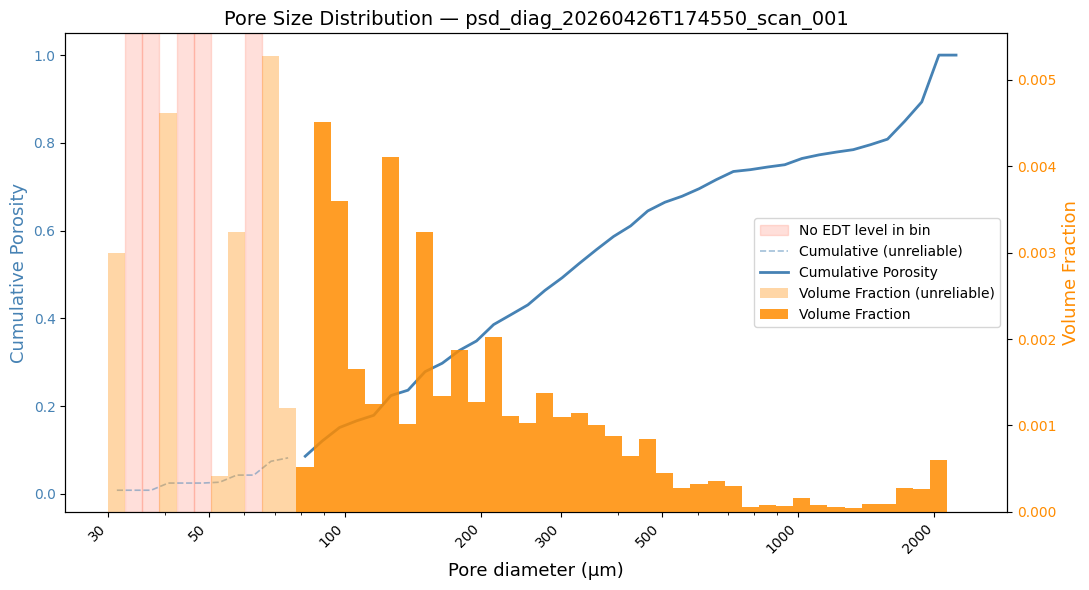

In [ ]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_folders = sorted(pathlib.Path(OUTPUT_ROOT).glob('psd_diag_*'))
if not run_folders:
    raise FileNotFoundError(f'No run folders found in {OUTPUT_ROOT}')
latest = run_folders[-1]
print(f'Using run folder: {latest}')

src_csv = latest / 'psd_table.csv'
if not src_csv.exists():
    raise FileNotFoundError(f'Missing expected file: {src_csv}')

# 1) Raw data CSV output
raw_df = pd.read_csv(src_csv)
raw_csv_path = latest / 'psd_raw_data.csv'
raw_df.to_csv(raw_csv_path, index=False)
print(f'Wrote raw CSV: {raw_csv_path}')

required_cols = {'Diameter_um', 'Differential_PSD'}
missing_cols = required_cols.difference(raw_df.columns)
if missing_cols:
    raise KeyError(f'Missing required columns in CSV: {sorted(missing_cols)}')

# 2) 20-bin PNG output for 30-150 um without mixing with outside-range pores
range_min, range_max = 30.0, 150.0
df = raw_df.copy()
df['Diameter_um'] = pd.to_numeric(df['Diameter_um'], errors='coerce')
df['Differential_PSD'] = pd.to_numeric(df['Differential_PSD'], errors='coerce')
df = df.dropna(subset=['Diameter_um', 'Differential_PSD'])

below = df[df['Diameter_um'] < range_min]
inside = df[(df['Diameter_um'] >= range_min) & (df['Diameter_um'] <= range_max)]
above = df[df['Diameter_um'] > range_max]

bin_edges = np.linspace(range_min, range_max, 21)  # exactly 20 bins
if inside.empty:
    raise ValueError('No Diameter_um values found inside 30-150 um range.')

inside = inside.copy()
inside['bin_idx'] = pd.cut(
    inside['Diameter_um'],
    bins=bin_edges,
    include_lowest=True,
    labels=False,
    right=True,
    duplicates='drop',
)

binned = inside.groupby('bin_idx', as_index=False)['Differential_PSD'].sum()
all_bins = pd.DataFrame({'bin_idx': np.arange(20, dtype=int)})
binned = all_bins.merge(binned, on='bin_idx', how='left').fillna({'Differential_PSD': 0.0})

centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
widths = np.diff(bin_edges)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    centers,
    binned['Differential_PSD'].values,
    width=widths * 0.95,
    align='center',
    color='steelblue',
    edgecolor='white',
    linewidth=0.7,
    label='Differential PSD (binned 30-150 um)'
)

ax.set_xlabel('Pore diameter (um)')
ax.set_ylabel('Differential PSD (sum within bin)')
ax.set_title('PSD in 30-150 um range (20 bins, strict range separation)')
ax.grid(axis='y', alpha=0.25)

summary_txt = (
    f'<30 um rows: {len(below)}\n'
    f'30-150 um rows: {len(inside)}\n'
    f'>150 um rows: {len(above)}'
 )
ax.text(
    0.99,
    0.98,
    summary_txt,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.8')
)

png_path = latest / 'psd_20bins_30_150um.png'
fig.tight_layout()
fig.savefig(png_path, dpi=200)
plt.show()

print(f'Wrote PNG: {png_path}')

## Step 9 — Preview Saved Outputs

Displays the PNG created in Step 8 and previews the first rows of `psd_raw_data.csv`.

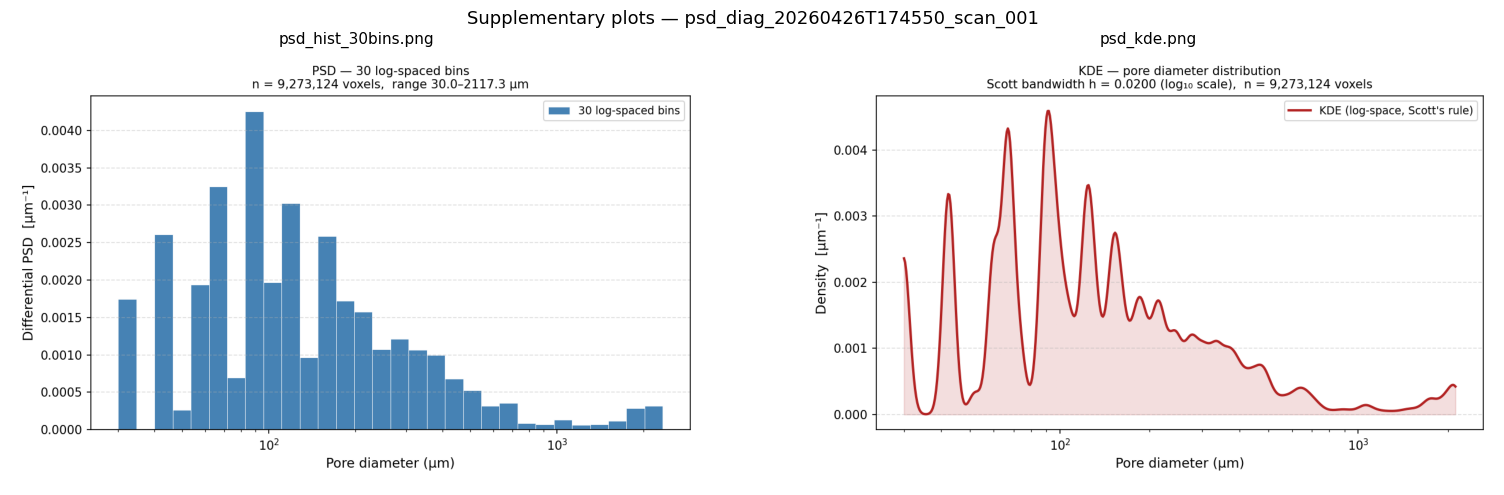

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

run_folders = sorted(Path(OUTPUT_ROOT).glob('psd_diag_*'))
if not run_folders:
    raise FileNotFoundError(f'No run folders found in {OUTPUT_ROOT}')
latest = run_folders[-1]

png_path = latest / 'psd_20bins_30_150um.png'
csv_path = latest / 'psd_raw_data.csv'

if not png_path.exists():
    raise FileNotFoundError(f'Missing PNG output: {png_path}')
if not csv_path.exists():
    raise FileNotFoundError(f'Missing CSV output: {csv_path}')

print(f'PNG: {png_path}')
print(f'CSV: {csv_path}')

img = mpimg.imread(str(png_path))
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.title(png_path.name)
plt.tight_layout()
plt.show()

preview = pd.read_csv(csv_path).head(10)
print('Raw CSV preview (first 10 rows):')
display(preview)